# Boundary Conditions and Convergence

Use boundary data and resolution changes to test whether wave-equation
errors decrease as expected.

Navigation: [Index](../index.ipynb) |
Previous: [Method of Lines and Runge-Kutta Methods](method_of_lines_and_rk.ipynb) |
Next: [Finite-Difference Playground](finite_difference_playground.ipynb)

## Learning Goals

- Inspect the generated ghost-zone boundary-condition source.
- Run the wave project at two resolutions.
- Compare diagnostic errors at the same physical time.
- Use error reduction as evidence that the boundary-handled calculation is working.

## Words for This Notebook

- **Boundary condition:** a rule for what happens at the edge of the grid.
- **Ghost zone:** extra grid cells outside the physical domain that let
  interior stencil code read neighboring values near a boundary.
- **Quadratic extrapolation:** a boundary rule that fills ghost zones from a
  quadratic fit to nearby interior values.
- **Resolution:** how many grid points are used to represent the domain.
- **Convergence factor:** the multiplier used to refine the grid.
- **Diagnostic row:** one line of output numbers written by the simulation.
- **Generated project file:** a C source, header, Makefile, or parameter file
  written by the NRPy example generator.

Use the code cells actively: first predict what should happen, then run the
cell, then explain the output in plain language. This predict-run-explain
pattern keeps the physics idea connected to the programming details.

## Table of Contents

- [Challenges](#Challenges)
- [Workflow Overview](#Workflow-Overview)
- [Workspace Setup](#Workspace-Setup)
- [Step 1: Generate the Boundary-Test Project](#Step-1:-Generate-the-Boundary-Test-Project)
- [Step 2: Inspect Generated Files](#Step-2:-Inspect-Generated-Files)
- [Step 3: Shorten the Boundary-Test Runtime](#Step-3:-Shorten-the-Boundary-Test-Runtime)
- [Step 4: Build the Boundary-Test Executable](#Step-4:-Build-the-Boundary-Test-Executable)
- [Step 5: Run the Coarse Boundary Test](#Step-5:-Run-the-Coarse-Boundary-Test)
- [Step 6: Run the Refined Boundary Test](#Step-6:-Run-the-Refined-Boundary-Test)
- [Step 7: Load Diagnostic Rows](#Step-7:-Load-Diagnostic-Rows)
- [Step 8: Plot Boundary-Test Error Histories](#Step-8:-Plot-Boundary-Test-Error-Histories)
- [Validation Check](#Validation-Check)

## Challenges

- **Ghost zones:** centered stencils near an edge need values outside the
  physical grid.
- **Quadratic extrapolation:** the generated project fills those ghost zones
  from nearby interior points, so the boundary source should show the
  extrapolation rule.
- **Matching times:** coarse and refined runs can write diagnostics on
  different grids, so the comparison uses only shared physical times.
- **Generated files:** the project writes source, build products, and
  diagnostics, so the notebook keeps them inside a temporary workspace.

The sections below generate the project, inspect the boundary source, run both
resolutions, then validate the boundary evidence and matching-time diagnostic
comparison.

## Workflow Overview

The Cartesian wave project uses generated C code for the wave update, boundary
conditions, diagnostics, and time stepping. Running with convergence factor 2
refines the grid and should reduce the diagnostic error.

## Import Boundary-Test Execution Helpers

These standard-library tools run commands, manage temporary project
directories, and clean command output.

If you are new to Python, do not study this helper cell line by line on a
first pass. Its job is practical: run terminal commands, shorten long command
output, and stop with a clear message if a required tool is missing. Focus
first on the cells that generate, inspect, build, run, and interpret the
physics project.

In [1]:
from pathlib import Path
import re, shutil, subprocess, sys, tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )

## Workspace Setup

The workspace keeps generated files separate from the tutorial source tree.

In [2]:
PROJECT_NAME = "wave_equation_cartesian"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_cartesian_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME
print("workspace:", WORKSPACE)
print("project path:", PROJECT_DIR)

workspace: /work/2-numerical_methods/nrpy_tutorial_cartesian__w26rnoa
project path: /work/2-numerical_methods/nrpy_tutorial_cartesian__w26rnoa/project/wave_equation_cartesian


## Step 1: Generate the Boundary-Test Project

This command invokes the same module a learner can run from a terminal. The
final check verifies that the expected project directory exists.

In [3]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_cartesian"]
print("generator command: python -m nrpy.examples.wave_equation_cartesian")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("project path:", PROJECT_DIR)

generator command: python -m nrpy.examples.wave_equation_cartesian


Finished! Now go into project/wave_equation_cartesian and type `make` to build, then ./wave_equation_cartesian to run.
    Parameter file can be found in wave_equation_cartesian.par
project path: /work/2-numerical_methods/nrpy_tutorial_cartesian__w26rnoa/project/wave_equation_cartesian


## Step 2: Inspect Generated Files

The generated project separates the boundary rule, time-step driver,
diagnostics, and runtime settings into different files:

| File | Role | What to inspect |
| --- | --- | --- |
| `apply_bcs.c` | Fills ghost zones | `FACE_UPDATE`, `NGHOSTS`, coefficients `3, -3, 1` |
| `MoL/MoL_step_forward_in_time.c` | Advances RK stages | calls to `apply_bcs` |
| `diagnostics.c` | Writes center-point errors | output filename and columns |
| `wave_equation_cartesian.par` | Runtime settings | final time and output cadence |

The complete `apply_bcs.c` file is short enough to print. On a first pass,
look for the face update macro, the ghost-zone loop, and the quadratic
extrapolation coefficients.

In [4]:
expected_generated_files = [
    "apply_bcs.c",
    "MoL/MoL_step_forward_in_time.c",
    "diagnostics.c",
    "wave_equation_cartesian.par",
]
missing_generated_files = [
    relative_path
    for relative_path in expected_generated_files
    if not (PROJECT_DIR / relative_path).is_file()
]
if missing_generated_files:
    raise FileNotFoundError(f"Missing generated files: {missing_generated_files}")
print("generated file inventory:")
for relative_path in expected_generated_files:
    print(relative_path)

apply_bcs_path = PROJECT_DIR / "apply_bcs.c"
apply_bcs_text = apply_bcs_path.read_text(encoding="utf-8", errors="replace")
print("--- apply_bcs.c ---")
print(apply_bcs_text)

mol_step_path = PROJECT_DIR / "MoL" / "MoL_step_forward_in_time.c"
mol_step_text = mol_step_path.read_text(encoding="utf-8", errors="replace")
apply_bcs_call_lines = [
    line.strip()
    for line in mol_step_text.splitlines()
    if "apply_bcs(" in line and not line.strip().startswith("*")
]
print("boundary-condition call sites in MoL_step_forward_in_time.c:")
for line in apply_bcs_call_lines:
    print(line)

generated file inventory:
apply_bcs.c
MoL/MoL_step_forward_in_time.c
diagnostics.c
wave_equation_cartesian.par
--- apply_bcs.c ---
#include "BHaH_defines.h"

// Declare boundary condition FACE_UPDATE macro,
//          which updates a single face of the 3D grid cube
//          using quadratic polynomial extrapolation.
const int MAXFACE = -1;
const int NUL = +0;
const int MINFACE = +1;
#define FACE_UPDATE(which_gf, i0min, i0max, i1min, i1max, i2min, i2max, FACEX0, FACEX1, FACEX2)                                                      \
  for (int i2 = i2min; i2 < i2max; i2++)                                                                                                             \
    for (int i1 = i1min; i1 < i1max; i1++)                                                                                                           \
      for (int i0 = i0min; i0 < i0max; i0++) {                                                                                                       \
       

## Step 3: Shorten the Boundary-Test Runtime

Only runtime values are changed so the notebook run finishes quickly. In the
full parameter-file dump, inspect `t_final`, `diagnostics_output_every`, and
`output_progress_every`.

In [5]:
parfile = PROJECT_DIR / "wave_equation_cartesian.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = par_text.replace("t_final = 8.0", "t_final = 0.3125")
par_text = par_text.replace(
    "diagnostics_output_every = 0.2", "diagnostics_output_every = 0.15625"
)
par_text = par_text.replace(
    "output_progress_every = 1", "output_progress_every = 1000000"
)
parfile.write_text(par_text, encoding="utf-8")
print("--- runtime wave_equation_cartesian.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

--- runtime wave_equation_cartesian.par ---
#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.15625  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.3125                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progress_every = 1000000       # (int)



## Step 4: Build the Boundary-Test Executable

The build step compiles generated C after checking that external build tools
are available.

In [6]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
print("build completed")
print("compiler output line count:", len(build_output.splitlines()))

build completed
compiler output line count: 16


## Step 5: Run the Coarse Boundary Test

The default run supplies the coarse diagnostic comparison.

In [7]:
default_output = run_command([f"./{PROJECT_NAME}"], PROJECT_DIR, timeout=90)
print("default run completed")
for line in default_output.splitlines()[:8]:
    if line.strip():
        print(line.rstrip())

default run completed
It: 0 t=0.000 / 0.3 = 0.00% dt=1/6.4 | t/h=0.00 ETA 0h00m00s


## Step 6: Run the Refined Boundary Test

The convergence-factor run uses the same executable with a refined grid.

In [8]:
refined_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=90)
print("refined run completed")
for line in refined_output.splitlines()[:8]:
    if line.strip():
        print(line.rstrip())

refined run completed
It: 0 t=0.000 / 0.3 = 0.00% dt=1/12.8 | t/h=0.00 ETA 0h00m00s


## Step 7: Load Diagnostic Rows

The diagnostic files provide the numerical evidence used for interpretation.
Each nonblank row has this schema:

| Column | Name | Meaning |
| --- | --- | --- |
| 0 | `time` | Physical simulation time. |
| 1 | `uu_relative_error` | Relative error in `uu` at the grid center. |
| 2 | `vv_relative_error` | Relative error in `vv` at the grid center. |
| 3 | `uu_numeric_center` | Numerical `uu` value at the grid center. |
| 4 | `uu_exact_center` | Exact `uu` value at the grid center. |

The next cell parses rows with named column constants and fails if the schema
changes.

In [9]:
TIME_COL = 0
UU_REL_ERROR_COL = 1
VV_REL_ERROR_COL = 2
UU_NUMERIC_COL = 3
UU_EXACT_COL = 4
DIAGNOSTIC_COLUMNS = {
    TIME_COL: "time",
    UU_REL_ERROR_COL: "uu_relative_error",
    VV_REL_ERROR_COL: "vv_relative_error",
    UU_NUMERIC_COL: "uu_numeric_center",
    UU_EXACT_COL: "uu_exact_center",
}
print("diagnostic columns:")
for index, name in DIAGNOSTIC_COLUMNS.items():
    print(index, name)

diagnostic_rows = {}
for diagnostic in sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")):
    rows = []
    for line_number, line in enumerate(
        diagnostic.read_text(encoding="utf-8", errors="replace").splitlines(),
        start=1,
    ):
        if not line.strip():
            continue
        values = [float(value) for value in line.split()]
        if len(values) != len(DIAGNOSTIC_COLUMNS):
            raise RuntimeError(
                f"{diagnostic.name}:{line_number} has {len(values)} columns."
            )
        rows.append(values)
    diagnostic_rows[diagnostic.name] = rows
    last_row = rows[-1]
    print(
        diagnostic.name,
        "rows:",
        len(rows),
        "last time:",
        f"{last_row[TIME_COL]:.6e}",
        "last uu relative error:",
        f"{last_row[UU_REL_ERROR_COL]:.6e}",
    )

diagnostic columns:
0 time
1 uu_relative_error
2 vv_relative_error
3 uu_numeric_center
4 uu_exact_center
out0d-conv_factor1.00.txt rows: 2 last time: 1.562500e-01 last uu relative error: 4.061498e-08
out0d-conv_factor2.00.txt rows: 2 last time: 1.562500e-01 last uu relative error: 2.797348e-09


## Step 8: Plot Boundary-Test Error Histories

A convergence comparison is easier to trust when the whole error history is
visible. The refined run should stay below the coarse run at matching times.

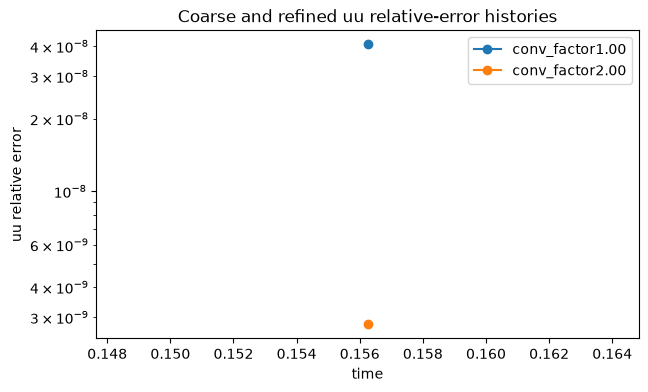

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for name, rows in sorted(diagnostic_rows.items()):
    positive_rows = [row for row in rows if row[UU_REL_ERROR_COL] > 0.0]
    times = [row[TIME_COL] for row in positive_rows]
    errors = [row[UU_REL_ERROR_COL] for row in positive_rows]
    label = name.replace("out0d-", "").replace(".txt", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("uu relative error")
plt.title("Coarse and refined uu relative-error histories")
plt.legend()
plt.show()

## Validation Check

This check combines source-level boundary evidence with runtime diagnostic
evidence. The source checks confirm that generated code fills ghost zones by
quadratic extrapolation and applies boundary conditions during RK stepping.
The diagnostic rows are trusted because `diagnostics.c` compares the numerical
center value against the generated exact solution.

Smooth fourth-order refinement should reduce the error by about 16 when the
grid spacing is halved. This check uses 12 as a conservative pass threshold:
it allows time-step rounding and finite-precision effects, but still catches
weak convergence.

Before running the check, predict which diagnostic file should have the
smaller error at the shared positive output time.

In [11]:
missing_generated_files = [
    relative_path
    for relative_path in expected_generated_files
    if not (PROJECT_DIR / relative_path).is_file()
]
if missing_generated_files:
    raise FileNotFoundError(f"Missing generated files: {missing_generated_files}")
required_boundary_terms = [
    "quadratic polynomial extrapolation",
    "FACE_UPDATE",
    "NGHOSTS",
    "+3.0",
    "1.0 *",
]
missing_boundary_terms = [
    term for term in required_boundary_terms if term not in apply_bcs_text
]
if missing_boundary_terms:
    raise RuntimeError(f"Missing boundary-source terms: {missing_boundary_terms}")
if apply_bcs_text.count("3.0 *") < 2:
    raise RuntimeError("Expected quadratic boundary source to use two 3.0 terms.")
if len(apply_bcs_call_lines) != 4:
    raise RuntimeError("Expected boundary conditions to be applied after four RK stages.")
coarse_name = "out0d-conv_factor1.00.txt"
fine_name = "out0d-conv_factor2.00.txt"
for diagnostic_name in [coarse_name, fine_name]:
    if not diagnostic_rows.get(diagnostic_name):
        raise RuntimeError(f"Expected nonempty diagnostics: {diagnostic_name}")
coarse_times = {
    round(row[TIME_COL], 12)
    for row in diagnostic_rows[coarse_name]
    if row[TIME_COL] > 0.0
}
fine_times = {
    round(row[TIME_COL], 12)
    for row in diagnostic_rows[fine_name]
    if row[TIME_COL] > 0.0
}
comparison_time = max(coarse_times.intersection(fine_times))
coarse_row = next(
    row
    for row in diagnostic_rows[coarse_name]
    if round(row[TIME_COL], 12) == comparison_time
)
fine_row = next(
    row
    for row in diagnostic_rows[fine_name]
    if round(row[TIME_COL], 12) == comparison_time
)
coarse_error = coarse_row[UU_REL_ERROR_COL]
fine_error = fine_row[UU_REL_ERROR_COL]
error_ratio = coarse_error / fine_error
minimum_expected_ratio = 12.0
print("comparison time:", f"{comparison_time:.6e}")
print("uu error coarse:", f"{coarse_error:.6e}")
print("uu error fine:", f"{fine_error:.6e}")
print("uu error ratio coarse/fine:", f"{error_ratio:.3f}")
print("minimum expected ratio:", f"{minimum_expected_ratio:.1f}")
print("boundary call count:", len(apply_bcs_call_lines))
if error_ratio <= minimum_expected_ratio:
    raise RuntimeError("Expected fourth-order refinement to reduce error by > 12.")

comparison time: 1.562500e-01
uu error coarse: 4.061498e-08
uu error fine: 2.797348e-09
uu error ratio coarse/fine: 14.519
minimum expected ratio: 12.0
boundary call count: 4


The comparison uses diagnostic rows at the same physical time. The smaller
refined-grid error is the evidence that the boundary-handled finite-difference
run is converging.

## Learning Check

After comparing errors, identify which diagnostic file corresponds to the
finer run, explain why matching physical time matters for the comparison, and
point to the line in `apply_bcs.c` that fills a ghost-zone face.

## Continue to the Finite-Difference Playground
- [Finite-Difference Playground](finite_difference_playground.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [Start-to-Finish Cartesian Wave Project](../3-wave_equation/start_to_finish_wave_cartesian.ipynb)